![header](content/img/header.PNG)

# Part 3 — Load and plot GloFAS historical discharge using Earthkit

Welcome to this companion notebook for the ICAR 2026 GloFAS workshop.

In this notebook, we follow a simple hydrological story.

Imagine that we have just downloaded a long archive of river discharge for Morocco. At first, the file is only a block of numbers: coordinates, dates, and discharge values. Step by step, we will turn this archive into information that a forecaster or hydrologist can read:

1. We open the historical GloFAS discharge file.
2. We inspect what is inside: variables, dates, latitude, longitude, and units.
3. We draw the first map to check that the data looks sensible.
4. We compress daily discharge into monthly values.
5. We build a monthly climatology: the “normal” river behaviour for each calendar month.
6. We select one catchment point and follow its discharge through time.
7. We compute reference thresholds, anomalies, and maps of anomalies.

By the end, the dataset should no longer feel like a black box. It becomes a small hydrological story: where the rivers are, how they usually behave, and when a given month is wetter or drier than normal.

## 1. Load and explore the historical discharge file

Our story starts with a single NetCDF file which we downloaded and prepared in the part 1 notebook. This file contains daily GloFAS historical river discharge for Morocco from 1979 to 2025.

Before doing any analysis, we need to open the file and ask a basic question:

**What exactly did we download?**

We use `xarray` to open the NetCDF file because it gives us a clear view of the dataset dimensions, coordinates, and variables.

In [1]:
import earthkit.data as ekd
import earthkit as ekh
import xarray as xr
import urllib.request
from pathlib import Path

DATA_DIR = Path("Data")
DATA_DIR.mkdir(exist_ok=True)

DATA_URL = (
    "https://sites.ecmwf.int/ecbox/ICAR2026/s/signed/r/"
    "cems-glofas-historical_morocco_1979_2026.nc"
    "?expiry=3JfaQK"
    "&signature=Y2bmtzBQ-p6ilJFabxAl7GLYLoxWgT8l4VS09MRgTdE"
)

DATA_PATH = DATA_DIR / "cems-glofas-historical_morocco_1979_2026.nc"

if not DATA_PATH.exists():
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

ds = xr.open_dataset(DATA_PATH)

print("Historical dataset loaded.")
print(f"Time period: {ds.valid_time.min().values} to {ds.valid_time.max().values}")
print(f"Grid size: {ds.sizes['latitude']} × {ds.sizes['longitude']}")

Historical dataset loaded.
Time period: 1979-01-02T00:00:00.000000000 to 2026-06-18T00:00:00.000000000
Grid size: 314 × 340


## 2. Inspect the NetCDF file

Before plotting or calculating anything, we inspect the dataset.

This is like opening a map before starting a journey. We need to know:

- which variable contains discharge,
- which dimension represents time,
- what the latitude and longitude ranges are,
- and whether the shape of the data matches what we expected.

### 2.1 Variable names and dimensions

Here we print the variables, dimensions, and coordinates.

For GloFAS historical discharge, the main variable used in this notebook is usually `dis24`, representing river discharge over the last 24 hours, expressed in `m³/s`.

In [3]:
print("Variables:")
print(list(ds.data_vars))

print("\nDimensions:")
for dim, size in ds.sizes.items():
    print(f"  • {dim}: {size}")

print("\nCoordinates:")
print(list(ds.coords))

Variables:
['dis24']

Dimensions:
  • valid_time: 17335
  • latitude: 314
  • longitude: 340

Coordinates:
['valid_time', 'surface', 'latitude', 'longitude']


### 2.2 Time range and spatial extent

Now we check the temporal and spatial coverage.

This confirms whether the file really covers the full historical period and the Morocco domain that we requested.

In [4]:
print('Time range :', ds.valid_time.values[0], '-->', ds.valid_time.values[-1])
print('Lat range  :', float(ds.latitude.min()), 'to', float(ds.latitude.max()))
print('Lon range  :', float(ds.longitude.min()), 'to', float(ds.longitude.max()))
print('Shape      :', ds['dis24'].shape)

Time range : 1979-01-02T00:00:00.000000000 --> 2026-06-18T00:00:00.000000000
Lat range  : 20.525 to 36.175
Lon range  : 342.525 to 359.475
Shape      : (17335, 314, 340)


### 2.3 First visual check with Matplotlib

The first plot is not meant to be beautiful. It is a quick diagnostic map.

At this stage, we only want to confirm that discharge values appear in the expected places and that the spatial subset looks correct.

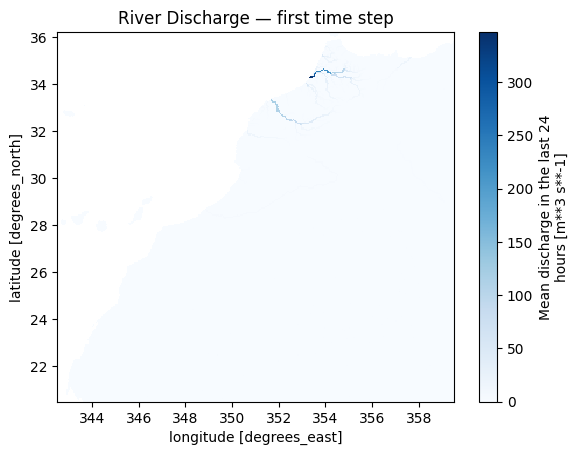

In [5]:
import matplotlib.pyplot as plt

ds['dis24'].isel(valid_time=0).plot(cmap='Blues')
plt.title('River Discharge — first time step')
plt.show()

### 2.4 First visual check with Earthkit plots

Now we use Earthkit plotting to produce a more map-oriented view.

This gives a bridge between the data access tool and a visual hydrological interpretation: rivers are no longer only numbers in a file; they start to appear as a spatial network.

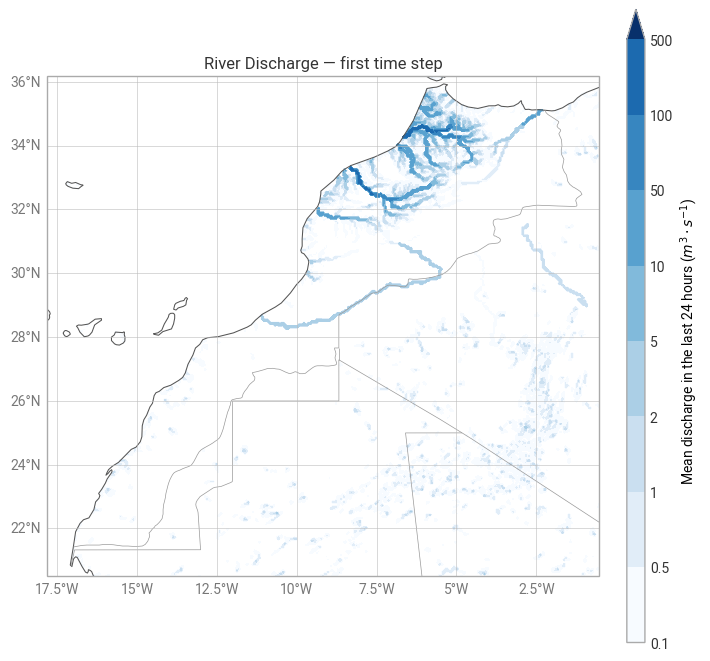

In [6]:
import earthkit.plots as ekp

style = ekp.styles.Style(
    colors='Blues',
    levels=[0.1, 0.5, 1, 2, 5, 10, 50, 100, 500],
    extend='max',
    units='m**3 s-1',
)

# Slice one time step as xarray DataArray
da_slice = ds['dis24'].isel(valid_time=0)

chart = ekp.Map()
chart.quickplot(da_slice, style=style)

chart.title('River Discharge — first time step')
chart.legend(location='right')
chart.coastlines()
chart.borders()
chart.gridlines()

chart.show()

## 3. Aggregate daily discharge into monthly means

Daily discharge is useful, but it can be noisy when we want to understand longer-term behaviour.

So the next step is to summarise each month with one value: the **monthly mean discharge**.

This answers a simple question:

> “For each month, what was the average river discharge?”

This monthly time series will also be the basis for the anomaly calculations later in the notebook.

In [ ]:
import earthkit.transforms as ekt

# Monthly means using earthkit
ds_monthly = ekh.transforms.temporal.monthly_reduce(ds, time_dim='valid_time')
print(ds_monthly)

### 3.1 Save the monthly NetCDF file

Once the monthly means are calculated, we save them.

The file will be used in the next parts of the training, better to load it that redo the calculations .

In [ ]:
ds_monthly.to_netcdf('/Data/cems-glofas-historical_morocco_1979_2026_Monthly.nc')

### 3.2 Reload the monthly file

Here we reload the monthly dataset.

This step shows that intermediate products can be saved and reused, instead of repeating the same aggregation every time the notebook is opened.

In [ ]:
ds_monthly = xr.open_dataset('/perm/ecm3644/ecmwf-training/ICAR2026/2026-icar-glofas-training/Data/cems-glofas-historical_morocco_1979_2026_Monthly.nc')
print(ds_monthly)

In [7]:
MONTHLY_FILE = DATA_DIR / "cems-glofas-historical_morocco_1979_2026_Monthly.nc"

MONTHLY_URL = (
    "https://sites.ecmwf.int/ecbox/ICAR2026/s/signed/r/"
    "cems-glofas-historical_morocco_1979_2026_Monthly.nc"
    "?expiry=3Jfbdt"
    "&signature=6JcBMShTxd9XiO1Gzw-__BcK0giHrL5wUk1kmhH0Gw8"
)

if not MONTHLY_FILE.exists():
    urllib.request.urlretrieve(MONTHLY_URL, MONTHLY_FILE)

ds_monthly = xr.open_dataset(MONTHLY_FILE)

print("Monthly historical dataset:")
print(ds_monthly)

Monthly historical dataset:
<xarray.Dataset> Size: 243MB
Dimensions:     (valid_time: 570, latitude: 314, longitude: 340)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 5kB 1979-01-01 ... 2026-06-01
  * latitude    (latitude) float64 3kB 36.17 36.12 36.08 ... 20.63 20.58 20.52
  * longitude   (longitude) float64 3kB 342.5 342.6 342.6 ... 359.4 359.4 359.5
    surface     float64 8B ...
Data variables:
    dis24       (valid_time, latitude, longitude) float32 243MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-18T22:18 GRIB to CDM+CF via cfgrib-0.9.1...


In [8]:
ds_monthly.valid_time.values

array(['1979-01-01T00:00:00.000000000', '1979-02-01T00:00:00.000000000',
       '1979-03-01T00:00:00.000000000', '1979-04-01T00:00:00.000000000',
       '1979-05-01T00:00:00.000000000', '1979-06-01T00:00:00.000000000',
       '1979-07-01T00:00:00.000000000', '1979-08-01T00:00:00.000000000',
       '1979-09-01T00:00:00.000000000', '1979-10-01T00:00:00.000000000',
       '1979-11-01T00:00:00.000000000', '1979-12-01T00:00:00.000000000',
       '1980-01-01T00:00:00.000000000', '1980-02-01T00:00:00.000000000',
       '1980-03-01T00:00:00.000000000', '1980-04-01T00:00:00.000000000',
       '1980-05-01T00:00:00.000000000', '1980-06-01T00:00:00.000000000',
       '1980-07-01T00:00:00.000000000', '1980-08-01T00:00:00.000000000',
       '1980-09-01T00:00:00.000000000', '1980-10-01T00:00:00.000000000',
       '1980-11-01T00:00:00.000000000', '1980-12-01T00:00:00.000000000',
       '1981-01-01T00:00:00.000000000', '1981-02-01T00:00:00.000000000',
       '1981-03-01T00:00:00.000000000', '1981-04-01

### 3.3 Quick plot of one monthly mean

We now look at one month only, for example december 2025.

This is another checkpoint: before doing climatology or anomaly calculations, we verify that the monthly data can be displayed correctly.

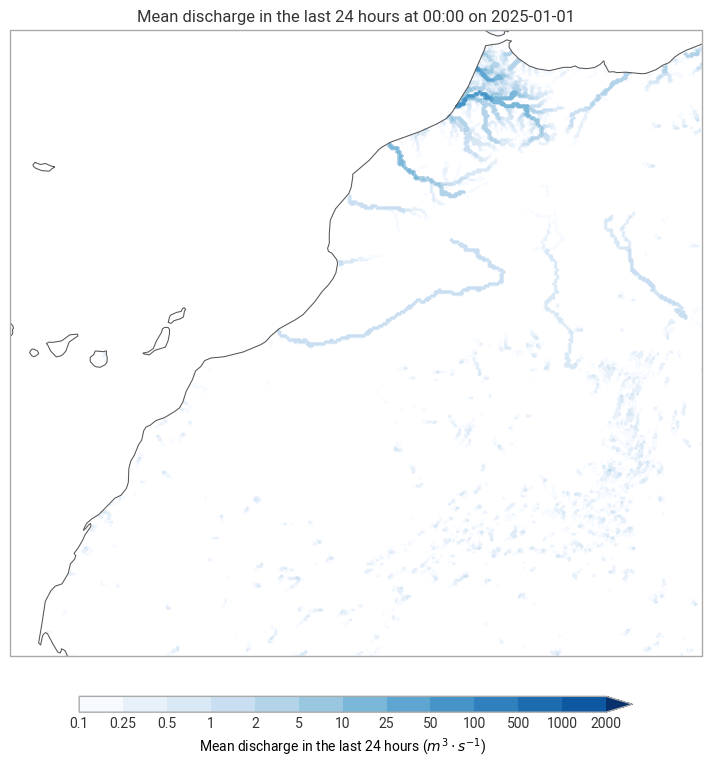

In [9]:
import xarray as xr
import numpy as np

dec2025 = ds_monthly.sel(valid_time='2025-01', method='nearest')
ekh.plots.quickplot(dec2025['dis24'])

## 4. Create discharge climatology maps

A climatology is the long-term average behaviour of the system.

Here, we ask:

> “What does a typical January look like? What about a typical February, March, and so on?”

For each calendar month, we average all years together. This gives us 12 maps: one for each month of the year.

### 4.1 Compute the long-term monthly climatology

We group the data by calendar month and compute the mean across all years.

For example, the January climatology is calculated from all Januaries between 1979 and 2025.

In [11]:
ds_clim = (
    ds_monthly["dis24"]
    .sel(valid_time=slice("1979-01-01", "2025-12-31"))
    .groupby("valid_time.month")
    .mean(dim="valid_time")
)

print("Monthly climatology created.")
print("Reference period: 1979-01-01 to 2025-12-31")
print("Output variable: ds_clim")
print(f"Months: {ds_clim.sizes['month']}")
print(f"Grid size: {ds_clim.sizes['latitude']} × {ds_clim.sizes['longitude']}")

Monthly climatology created.
Reference period: 1979-01-01 to 2025-12-31
Output variable: ds_clim
Months: 12
Grid size: 314 × 340


Save the file to use it later :
ds_clim.to_netcdf('/Data/cems-glofas-historical_morocco_1979_2026_Climatology.nc')

### 4.2 Plot the 12 monthly climatology maps

This figure shows the seasonal rhythm of river discharge across Morocco.

Instead of looking at one isolated day, we see how the average spatial pattern changes from winter to summer and back again.

#### GloFAS Historical 1979–2025
Morocco Long-term monthly mean river discharge

/etc/ecmwf/ssd/ssd1/jupyterhub/ecm3644-jupyterhub/tmpdirs/ecm3644.16936260/ipykernel_2130260/3449973380.py:3: DeprecationWarning: The 'size' argument is deprecated and will be removed in a future release. Use 'figsize' instead.
  figure = ekh.plots.Figure(rows=3, columns=4, size=(16, 10))


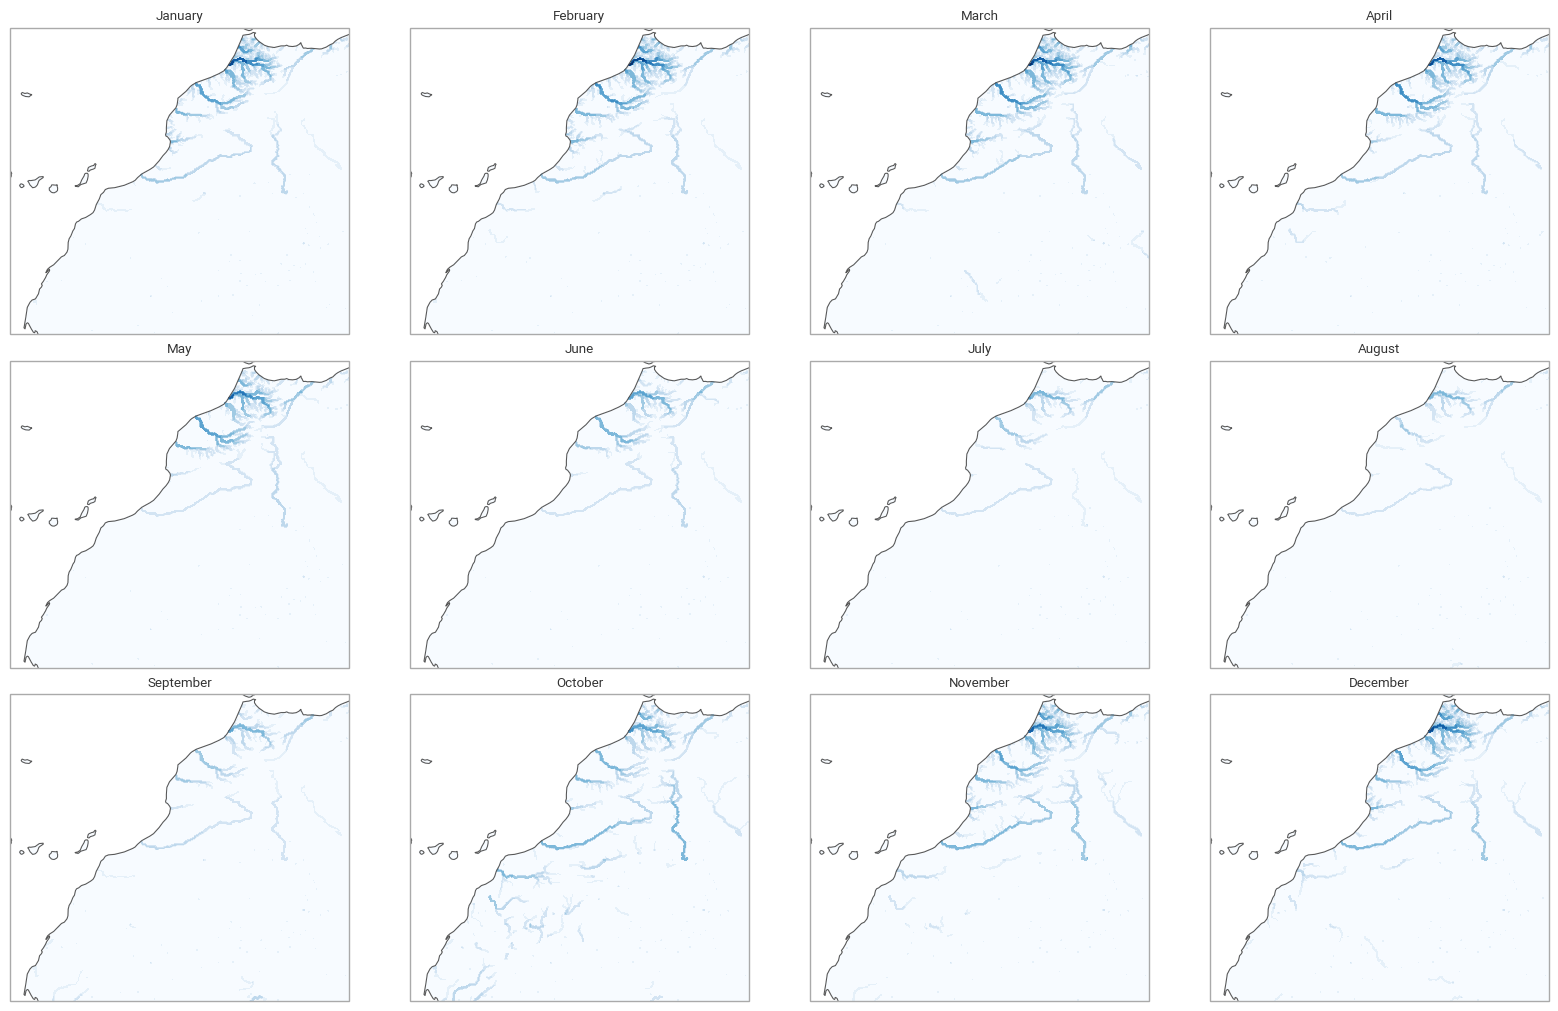

In [21]:
import matplotlib.pyplot as plt

figure = ekh.plots.Figure(rows=3, columns=4, size=(16, 10))

dis_style = ekh.plots.styles.Style(
    levels=[0, 1, 2, 5, 10, 20, 50, 100, 150, 200, 300, 400, 500],
    colors="Blues",
    units="m**3 s-1",
)

for i in range(12):
    figure.add_map(i // 4, i % 4)

figure.quickplot(ds_clim, style=dis_style)

figure.land()
figure.coastlines()

figure.subplot_titles("{month}")

figure.show()

### 5.1 Select one point of interest

The longitude in this NetCDF file uses the `0–360°` convention.

So a location such as `-8.1588°` becomes:

```python
351.8412 = -8.1588 + 360
```

We select the nearest GloFAS grid point to the chosen latitude and longitude.

In [22]:
# Oum Er-Rbia catchment — adjust lat/lon to your point of interest
LAT_POINT =33.2124
LON_POINT =  351.8412 # (the longitude is 0-360 and not -180,180)
ds_point = ds.sel(latitude=LAT_POINT, longitude=LON_POINT, method='nearest')
print(ds_point)

<xarray.Dataset> Size: 208kB
Dimensions:     (valid_time: 17335)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 139kB 1979-01-02 ... 2026-06-18
    surface     float64 8B ...
    latitude    float64 8B 33.23
    longitude   float64 8B 351.8
Data variables:
    dis24       (valid_time) float32 69kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-18T22:18 GRIB to CDM+CF via cfgrib-0.9.1...


### 5.2 Plot the full daily discharge time series

This plot shows the complete daily discharge history at the selected point.

It is useful for seeing high-flow events, dry periods, and the general variability of the river through time.

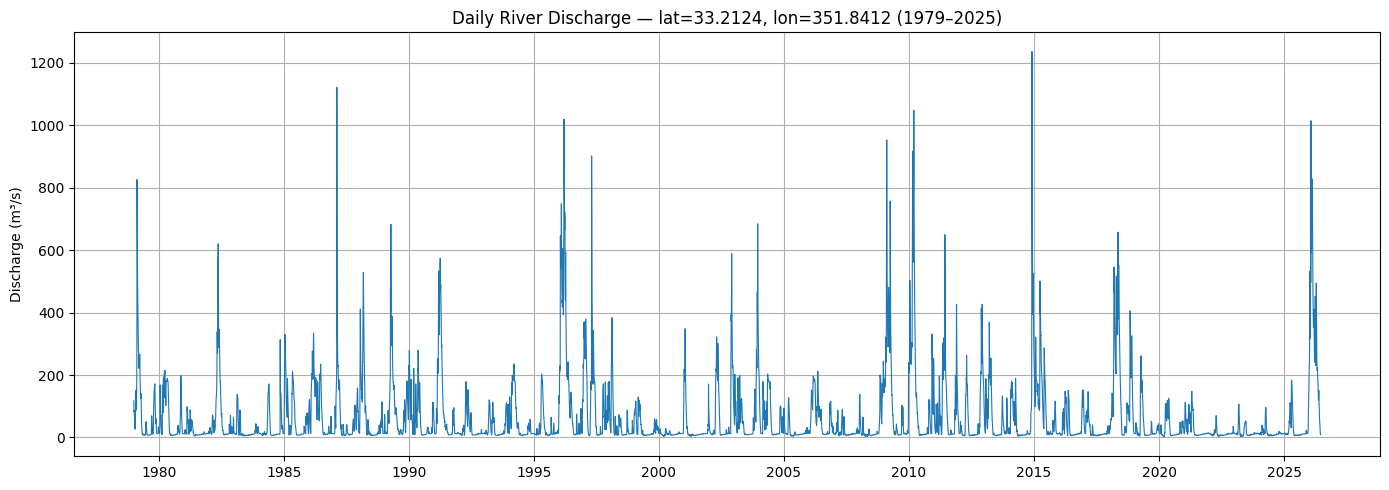

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    ds_point['valid_time'],
    ds_point['dis24'],
    linewidth=0.8,
)

ax.set_title(
    f'Daily River Discharge — lat={LAT_POINT}, lon={LON_POINT} (1979–2025)'
)

ax.set_ylabel('Discharge (m³/s)')

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.grid(True)

plt.tight_layout()
plt.show()

### 5.3 Plot a zoomed view for one decade

The full 1979–2025 time series can be dense. To see individual events more clearly, we zoom into a shorter period.

Here, we focus on 2010–2020, but this period can be changed easily.

/etc/ecmwf/ssd/ssd1/jupyterhub/ecm3644-jupyterhub/tmpdirs/ecm3644.16936260/ipykernel_2130260/748037627.py:3: DeprecationWarning: The 'size' argument is deprecated and will be removed in a future release. Use 'figsize' instead.
  fig2 = ekh.plots.Figure(rows=1, columns=1, size=(14, 5))


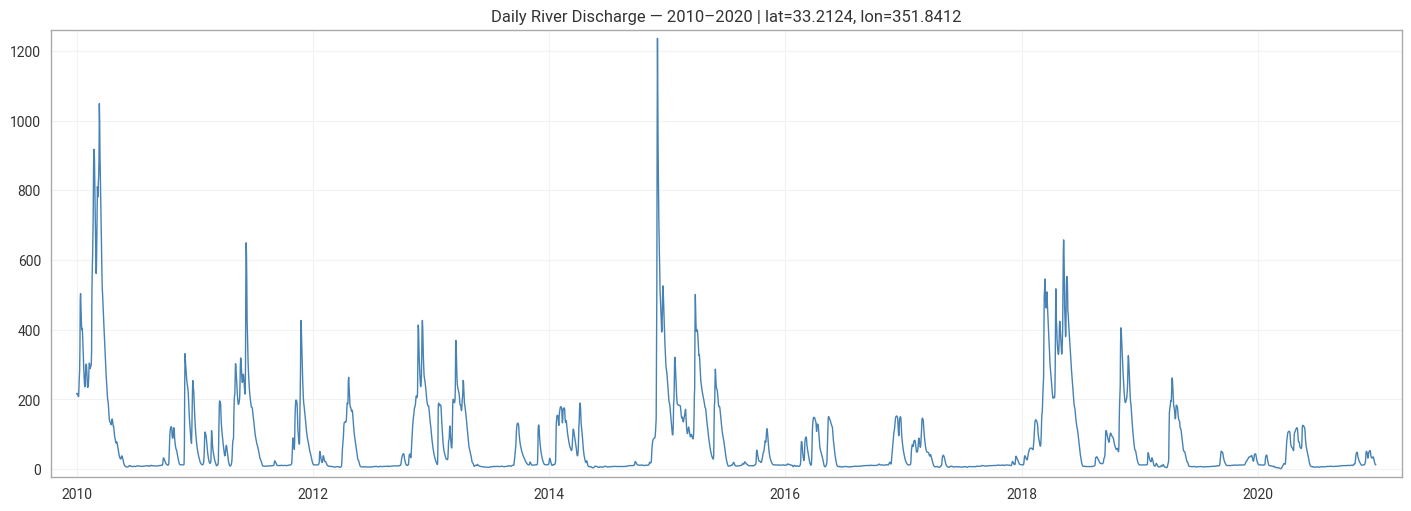

In [25]:
ds_zoom = ds_point.sel(valid_time=slice('2010-01-01', '2020-12-31'))

fig2 = ekh.plots.Figure(rows=1, columns=1, size=(14, 5))
sp2 = fig2.add_subplot(0, 0)

sp2.line(
    x=ds_zoom['valid_time'].values,
    y=ds_zoom['dis24'].values,
    linewidth=1.0,
    color='steelblue',
)

sp2.title(f'Daily River Discharge — 2010–2020 | lat={LAT_POINT}, lon={LON_POINT}')
# Note: Earthkit subplot does not support set_major_xticks().
# For detailed date ticks, use the Matplotlib examples below.

fig2.show()

## 6. Compute and visualise the seasonal cycle at the catchment

Now we ask a more hydrological question:

> “What is the normal seasonal behaviour of this river?”

To answer this, we group the point time series by calendar month and calculate statistics such as the mean, standard deviation, minimum, and maximum.

### 6.1 Compute mean monthly discharge at the selected point

This table summarises the typical monthly behaviour at the selected point.

It helps identify the months when discharge is usually high and the months when the river is usually low.

In [46]:
import pandas as pd

df_point = pd.DataFrame({
    'date': ds_point['valid_time'].values,
    'discharge': ds_point['dis24'].values
})
df_point['month'] = df_point['date'].dt.month

monthly_clim = df_point.groupby('month')['discharge'].agg(['mean', 'std', 'min', 'max'])
print(monthly_clim)

             mean         std        min          max
month                                                
1       81.293785  116.354263   7.328125  1014.312500
2      113.939377  173.527618   4.296875  1121.281250
3      127.041817  163.562073   1.562500  1048.281250
4      117.029854  127.712219   1.625000   901.781250
5       92.418663  104.894974   3.625000   657.593750
6       46.845196   70.550697   4.687500   649.343750
7       15.126555   19.632704   4.906250   159.375000
8        9.168883    2.955844   6.218750    35.609375
9       15.074409   16.599705   7.570312   132.203125
10      25.498327   28.310373   9.746094   186.710938
11      54.837845   76.695259  10.453125   588.812500
12      73.422081  113.609016  11.265625  1235.921875


### 6.2 Plot the seasonal cycle with an uncertainty range

The line shows the average seasonal cycle.

The surrounding range gives a simple idea of variability from year to year. This helps learners understand that a river does not behave exactly the same way every year.

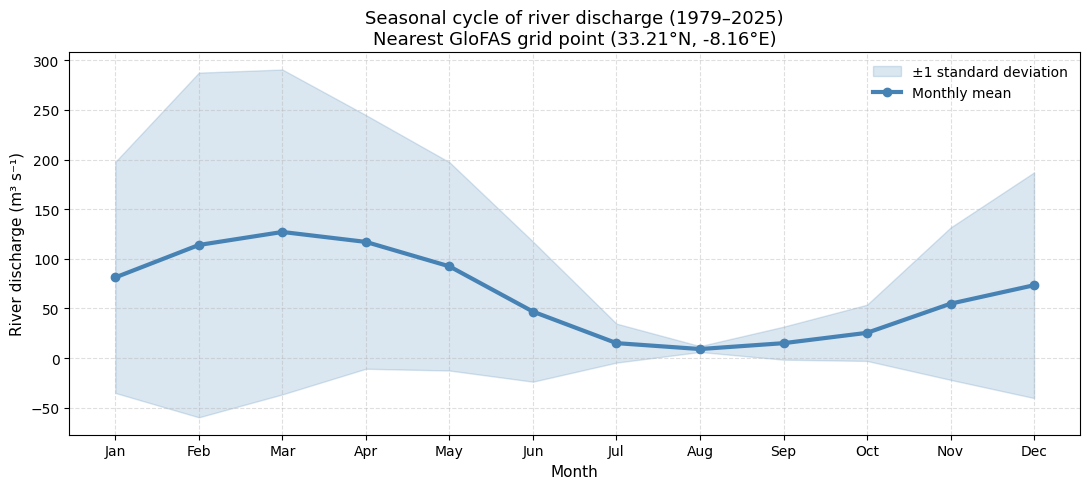

In [29]:
import calendar
import matplotlib.pyplot as plt

months = range(1, 13)
month_labels = [calendar.month_abbr[m] for m in months]

means = monthly_clim["mean"].values
stds = monthly_clim["std"].values

fig, ax = plt.subplots(figsize=(11, 5))

# ±1 standard deviation
ax.fill_between(
    months,
    means - stds,
    means + stds,
    color="steelblue",
    alpha=0.20,
    label="±1 standard deviation",
)

# Mean climatology
ax.plot(
    months,
    means,
    color="steelblue",
    linewidth=3,
    marker="o",
    markersize=6,
    label="Monthly mean",
)

ax.set_xticks(months)
ax.set_xticklabels(month_labels)

ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("River discharge (m³ s⁻¹)", fontsize=11)

ax.set_title(
    "Seasonal cycle of river discharge (1979–2025)\n"
    f"Nearest GloFAS grid point ({LAT_POINT:.2f}°N, {LON_POINT-360:.2f}°E)",
    fontsize=13,
)

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## 7. From monthly averages to thresholds and anomalies

We now move from description to interpretation.

Until now, we have looked at discharge values directly. But a forecaster often wants to know whether a month is **normal**, **unusually dry**, or **unusually wet**.

To do that, we need three ingredients:

1. **Monthly average discharge** from the daily time series.
2. **Reference thresholds** such as Q10 and Q90 for each calendar month.
3. **Anomalies**, calculated as the difference between the observed monthly value and the long-term monthly reference.

In this section, we calculate these quantities first for the selected catchment point, then for the full Morocco map.

### 7.1 Calculate monthly average discharge from the daily point time series

The daily hydrograph is detailed, but for anomalies we usually work at monthly scale.

Here we resample the daily discharge values into calendar months and calculate the monthly mean.

Each row in the resulting table represents one month, for example January 1979, February 1979, and so on.

In [44]:
# Convert the selected point into a clean pandas time series
df_point = pd.DataFrame({
    "date": pd.to_datetime(ds_point["valid_time"].values),
    "discharge": ds_point["dis24"].values,
})


df_point = df_point.set_index("date").sort_index()

# Monthly average discharge from daily values
df_monthly_point = (
    df_point["discharge"]
    .resample("MS")          # MS = month start
    .mean()
    .to_frame("monthly_mean")
)

df_monthly_point["year"] = df_monthly_point.index.year
df_monthly_point["month"] = df_monthly_point.index.month

print(df_monthly_point.head())
print(df_monthly_point.tail())

            monthly_mean  year  month
date                                 
1979-01-01     68.583855  1979      1
1979-02-01    342.383942  1979      2
1979-03-01    287.242950  1979      3
1979-04-01    122.832291  1979      4
1979-05-01     10.567540  1979      5
            monthly_mean  year  month
date                                 
2026-02-01    665.358276  2026      2
2026-03-01    349.773193  2026      3
2026-04-01    307.502075  2026      4
2026-05-01    145.932465  2026      5
2026-06-01     29.887154  2026      6


### 7.2 Calculate monthly reference thresholds Q10 and Q90

Q10 and Q90 are reference thresholds calculated from the historical monthly values.

In this notebook, we calculate them separately for each calendar month.

For example:

- January Q10 is calculated from all January monthly means in the reference period.
- January Q90 is calculated from all January monthly means in the reference period.
- The same is repeated for February, March, and the other months.

Here we use `1991–2020` as a standard reference period. You can change it to the full period `1979–2025` if you want the thresholds to use all available data.

Interpretation:

- Values below **Q10** are unusually low for that month.
- Values above **Q90** are unusually high for that month.
- Values between Q10 and Q90 are within the central historical range.

In [32]:
# Choose the reference period
REF_START = "1979-01-01"
REF_END   = "2025-12-31"

df_ref = df_monthly_point.loc[REF_START:REF_END].copy()

# Q10, mean, and Q90 for each calendar month
monthly_reference = (
    df_ref
    .groupby("month")["monthly_mean"]
    .quantile([0.10, 0.50, 0.90])
    .unstack()
    .rename(columns={0.10: "Q10", 0.50: "median", 0.90: "Q90"})
)

monthly_reference["mean"] = df_ref.groupby("month")["monthly_mean"].mean()

print(monthly_reference)

             Q10     median         Q90        mean
month                                              
1      11.753377  35.481853  200.963004   72.965782
2      11.023438  44.866631  284.066183  102.554718
3      11.760484  69.702621  336.343549  122.302849
4      10.279166  79.278122  285.358545  112.977249
5       8.483770  58.486897  202.064316   91.280075
6       6.778750  14.470834  134.091879   47.061680
7       6.841431   8.388104   33.054335   15.126554
8       7.878226   8.721271   10.405846    9.168883
9       9.638099  10.567448   26.017501   15.074409
10     11.130847  16.580645   53.813105   25.498327
11     12.117552  29.116146  139.384012   54.837845
12     12.625403  30.956654  181.868451   73.422081


### 7.3 Plot monthly discharge with Q10 and Q90 thresholds

Now we plot the monthly time series together with its monthly reference envelope.

Because Q10 and Q90 depend on the calendar month, the threshold line changes through the year. This is important: a discharge value that is high in August may be normal in February.

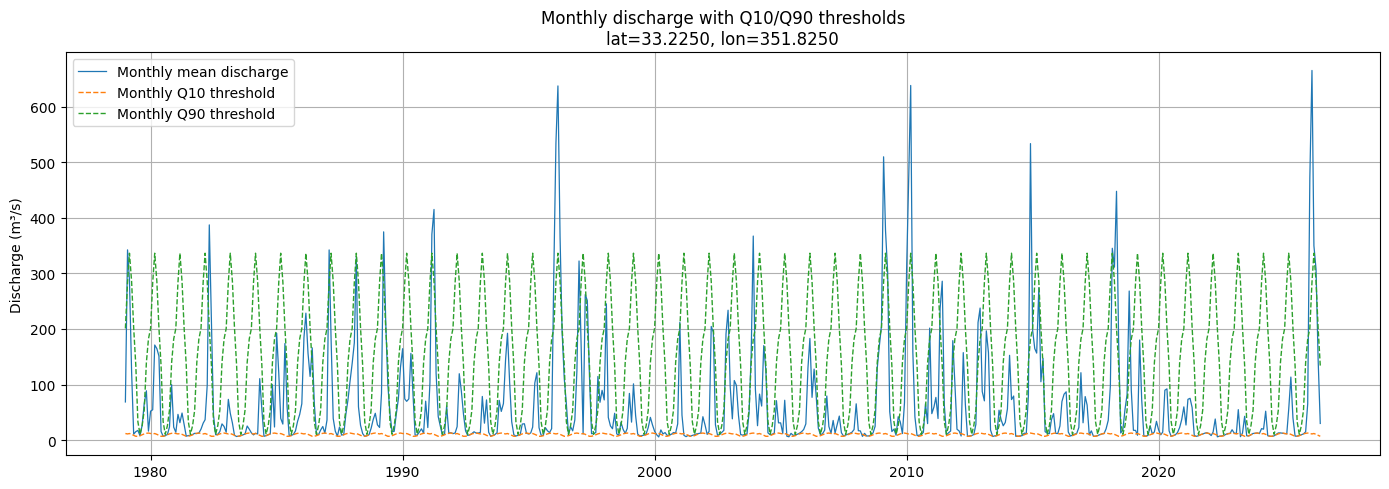

In [33]:
# Add the monthly reference values to each month of the full time series
df_monthly_plot = df_monthly_point.join(
    monthly_reference[["Q10", "Q90", "mean"]],
    on="month"
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_monthly_plot.index,
    df_monthly_plot["monthly_mean"],
    linewidth=0.9,
    label="Monthly mean discharge",
)

ax.plot(
    df_monthly_plot.index,
    df_monthly_plot["Q10"],
    linewidth=1.0,
    linestyle="--",
    label="Monthly Q10 threshold",
)

ax.plot(
    df_monthly_plot.index,
    df_monthly_plot["Q90"],
    linewidth=1.0,
    linestyle="--",
    label="Monthly Q90 threshold",
)

ax.set_title(
    f"Monthly discharge with Q10/Q90 thresholds\n"
    f"lat={float(ds_point.latitude):.4f}, lon={float(ds_point.longitude):.4f}"
)
ax.set_ylabel("Discharge (m³/s)")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

### 7.4 Calculate and plot monthly discharge anomalies

An anomaly is the difference between the observed value and the reference value.

Here we calculate:

```text
monthly anomaly = monthly discharge - long-term monthly mean
```

This means that each month is compared with its own normal value.

A positive anomaly means the month was wetter or higher-flow than normal.  
A negative anomaly means the month was drier or lower-flow than normal.

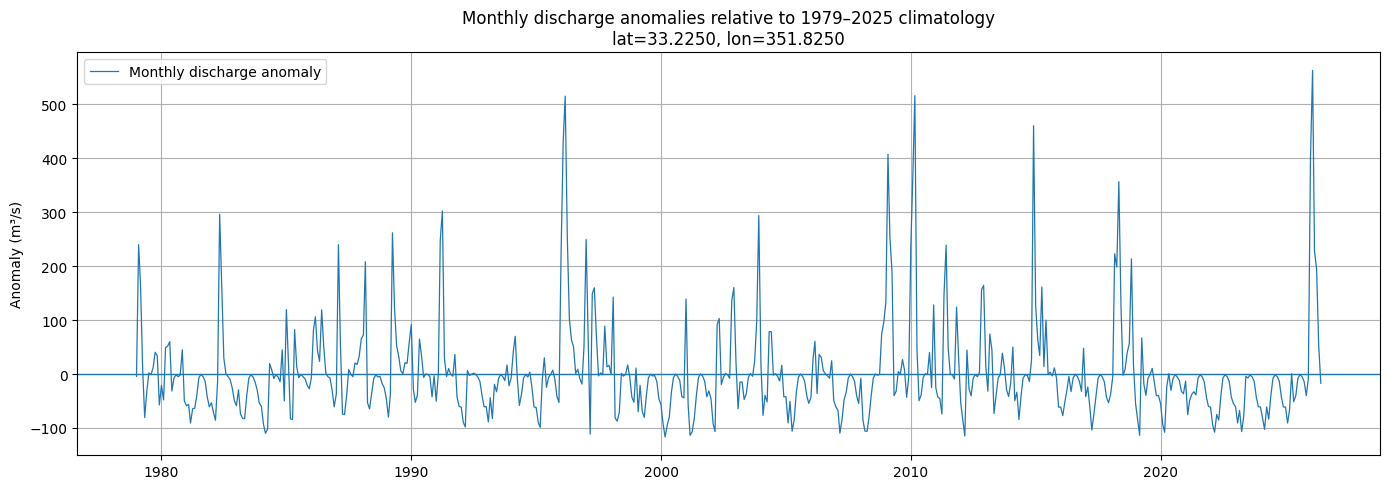

In [34]:
# Monthly anomaly at the selected point
df_monthly_plot["anomaly"] = (
    df_monthly_plot["monthly_mean"] - df_monthly_plot["mean"]
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(0, linewidth=1)

ax.plot(
    df_monthly_plot.index,
    df_monthly_plot["anomaly"],
    linewidth=0.9,
    label="Monthly discharge anomaly",
)

ax.set_title(
    f"Monthly discharge anomalies relative to {REF_START[:4]}–{REF_END[:4]} climatology\n"
    f"lat={float(ds_point.latitude):.4f}, lon={float(ds_point.longitude):.4f}"
)
ax.set_ylabel("Anomaly (m³/s)")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

## 8. Maps of monthly discharge anomalies

The point analysis tells the story of one catchment.

Now we return to the map and ask the same question spatially:

> “Where was discharge higher or lower than normal during a selected month?”

To do this, we calculate monthly means for every grid cell, build a monthly climatology map, and subtract the climatology from the selected month.

### 8.1 Build monthly mean maps from daily discharge

This step converts the full daily gridded dataset into monthly mean maps.

The result has one map per month instead of one map per day.

In [36]:
# Monthly mean discharge maps
ds_monthly_maps = ds["dis24"].resample(valid_time="MS").mean()

print(ds_monthly_maps)

<xarray.DataArray 'dis24' (valid_time: 570, latitude: 314, longitude: 340)> Size: 243MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        

### 8.2 Build reference climatology maps

Here we calculate the normal discharge map for each calendar month.

Again, we use `1975–2025` as the reference period, but this can be changed.

In [38]:
# Reference climatology maps for each calendar month
ref_monthly_maps = ds_monthly_maps.sel(valid_time=slice(REF_START, REF_END))

clim_maps = ref_monthly_maps.groupby("valid_time.month").mean("valid_time")

#print(clim_maps)

### 8.3 Plot an anomaly map for one selected month

Now we select one month and subtract the corresponding climatological month.

For example, if we choose January 2010, it is compared with the average January over the reference period.

The map shows:

- positive values where discharge was above normal,
- negative values where discharge was below normal.

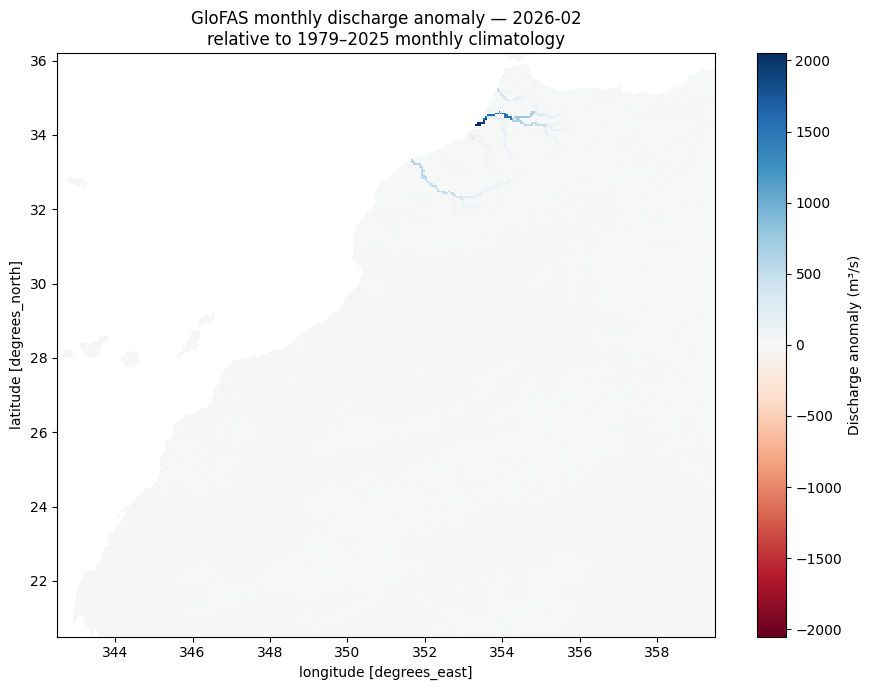

In [39]:
# Select the month to analyse
TARGET_MONTH = "2026-02-01"

selected_month = ds_monthly_maps.sel(valid_time=TARGET_MONTH)
target_calendar_month = int(selected_month["valid_time.month"])

anomaly_map = selected_month - clim_maps.sel(month=target_calendar_month)

# Plot with Matplotlib/xarray
fig, ax = plt.subplots(figsize=(9, 7))

anomaly_map.plot(
    ax=ax,
    cmap="RdBu",
    center=0,
    cbar_kwargs={"label": "Discharge anomaly (m³/s)"},
)

ax.set_title(
    f"GloFAS monthly discharge anomaly — {TARGET_MONTH[:7]}\n"
    f"relative to {REF_START[:4]}–{REF_END[:4]} monthly climatology"
)

plt.tight_layout()
plt.show()

### 8.4 Optional: percentage anomaly map

Sometimes the absolute anomaly is difficult to compare between large and small rivers.

A difference of `20 m³/s` may be very important for a small river but less important for a large river.

For this reason, we can also calculate percentage anomaly:

```text
percentage anomaly = 100 × anomaly / climatology
```

Use this carefully where climatological discharge is very close to zero.

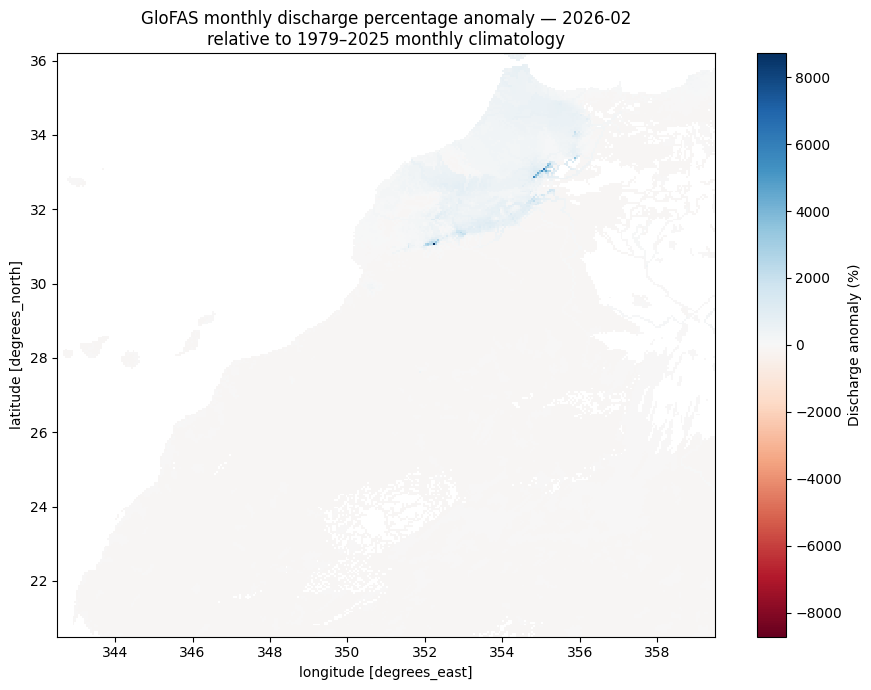

In [40]:
# Optional percentage anomaly map
clim_selected = clim_maps.sel(month=target_calendar_month)

percent_anomaly_map = 100 * anomaly_map / clim_selected.where(clim_selected > 0)

fig, ax = plt.subplots(figsize=(9, 7))

percent_anomaly_map.plot(
    ax=ax,
    cmap="RdBu",
    center=0,
    cbar_kwargs={"label": "Discharge anomaly (%)"},
)

ax.set_title(
    f"GloFAS monthly discharge percentage anomaly — {TARGET_MONTH[:7]}\n"
    f"relative to {REF_START[:4]}–{REF_END[:4]} monthly climatology"
)

plt.tight_layout()
plt.show()

## 9. What we have built

We started with a historical daily discharge file.

Then we gradually transformed it into hydrological indicators:

- daily maps and time series,
- monthly average discharge,
- long-term monthly climatology,
- monthly Q10 and Q90 reference thresholds,
- anomaly time series at one catchment point,
- and anomaly maps across Morocco.

This workflow is useful because it connects data access with interpretation. Learners can see not only how to open a GloFAS file, but also how to ask practical hydrological questions from it.

### 9.1 Annual maximum discharge

Finally, we extract the maximum daily discharge for each year.

This is useful for identifying years with strong high-flow events and for discussing interannual variability.

In [45]:
df_annual_max = (
    df_point
    .set_index("date")
    .resample("YE")["discharge"]
    .max()
)

fig4 = ekh.plots.Figure(rows=1, columns=1, size=(12, 5))
sp4 = fig4.add_subplot(0, 0)

sp4.line(
    x=df_annual_max.index.values,
    y=df_annual_max.values,
    linewidth=1.5,
    color='darkblue',
)

sp4.title(f'Annual Maximum Daily Discharge (1979–2025)\nlat={LAT_POINT}, lon={LON_POINT}')
# Note: Earthkit subplot does not support set_major_xticks().
# For detailed date ticks, use the Matplotlib examples below.

fig4.show()

KeyError: "None of ['date'] are in the columns"

In [ ]:
df_point = (
    ds["dis24"]
    .sel(valid_time=slice("1979-01-01", "2025-12-31"))
    .to_dataframe()
    .reset_index()
)

df_annual_max = (
    df_point
    .set_index("valid_time")
    .resample("YE")["dis24"]
    .max()
)
sp4.line(
    x=df_annual_max.index.values,
    y=df_annual_max.values,
    linewidth=1.5,
    color="darkblue",
)

In [ ]:
da_point = ds_point["dis24"].sel(valid_time=slice("1979-01-01", "2025-12-31"))

annual_max = da_point.resample(valid_time="YE").max()

fig4 = ekh.plots.Figure(rows=1, columns=1, size=(12, 5))
sp4 = fig4.add_subplot(0, 0)

sp4.line(
    x=annual_max.valid_time.values,
    y=annual_max.values,
    linewidth=1.5,
)

sp4.title(
    f"Annual Maximum Daily Discharge (1979–2025)\n"
    f"lat={LAT_POINT}, lon={LON_POINT}"
)

fig4.show()